<a href="https://colab.research.google.com/github/WayneNganju/D-10-Lab-on-Regression/blob/main/D10_food_delivery_orders__ARM_~_Lab_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D10: Food Delivery Order Association Rule Mining

**Dataset:** `food_delivery_orders.csv`  
**Method:** Association Rule Mining  
**Team:** D10  

## Team Introduction

This notebook was completed by Group D10 using food-delivery order data. The aim is to identify food items that customers frequently order together.

The resulting rules can support meal bundles, checkout recommendations, and targeted promotions. Association rule mining is exploratory: there is no target variable to predict. Instead, the analysis identifies recurring item combinations in customer orders.

| Team Member | ID Number | Primary Contribution |
|---|---:|---|
| Wayne Nganju | 146832 | Team lead; notebook setup, data loading, EDA, transaction-basket construction, coordination, and final integration. |
| Vanessa Warui | 152142 | Frequent itemset generation and minimum-support selection. |
| Natasha Njoroge | 150567 | Rule generation, confidence/lift threshold selection, and redundancy removal. |
| Ibrahim Omoi | 165042 | Temporal rule validation and recommendation-function development. |
| Melvin Muriithi | 152384 | Rule visualization, persistence, academic report, business analysis, and recommendations. |

The work will be completed in sequence so that rule thresholds and recommendations are based on the actual food-delivery data rather than copied from another dataset.

## 1. Environment Setup and Imports

This section prepares the Python environment for association rule mining.

The `mlxtend` library provides tools for one-hot encoding transactions and for mining frequent itemsets and rules using algorithms such as Apriori and FP-Growth.

In [1]:
%pip install -q mlxtend

In [2]:
import sys
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print(f"Python version: {sys.version.split()[0]}")
print("Environment ready for association rule mining.")

Python version: 3.13.15
Environment ready for association rule mining.


In [3]:
DATA_URL = (
    "https://raw.githubusercontent.com/course-files/ClusteringandAssociationRuleMining/main/data/food_delivery_orders.csv"
)

orders = pd.read_csv(
    DATA_URL,
    parse_dates=["transaction_date"]
)

print(f"Shape: {orders.shape[0]} order lines, {orders.shape[1]} columns")
print(f"Unique orders: {orders['order_id'].nunique()}")
print(f"Unique items: {orders['item_id'].nunique()}")
print(
    f"Date range: {orders['transaction_date'].min().date()} "
    f"to {orders['transaction_date'].max().date()}"
)

display(orders.head(8))

Shape: 9842 order lines, 6 columns
Unique orders: 3800
Unique items: 15
Date range: 2025-01-01 to 2025-06-30


,order_id,transaction_date,item_id,item_name,category,price_kes
0,1,2025-05-06,F04,Chicken Wings,Fast Food,500
1,1,2025-05-06,F15,Ice Cream,Dessert,250
2,2,2025-04-22,F13,Chapati,Local,50
3,3,2025-06-02,F10,Chicken Biryani,Indian,550
4,3,2025-06-02,F11,Raita,Indian,100
5,3,2025-06-02,F12,Naan Bread,Indian,80
6,4,2025-06-02,F07,California Roll Sushi,Japanese,700
7,5,2025-01-24,F12,Naan Bread,Indian,80


**Initial Data Understanding**

The dataset contains 9,842 food-order line items from 3,800 unique customer orders. Each row represents one food item included in an order rather than one complete transaction basket.

The dataset contains 15 unique food items and covers orders made from 1 January 2025 to 30 June 2025.

`order_id` identifies the order, while `transaction_date` records when the order was made. These fields will not be treated as food items during association rule mining. The rules will be mined using `item_id`, while `item_name` and `category` will be used later to translate the rules into readable food recommendations.

## 2. Data Quality and Basket Size

The food-delivery dataset contains raw order-line data, where each row represents one food item in an order.

Before building transaction baskets, the data quality and the number of items per order are examined. Basket size is important because association rule mining identifies food items that occur together within the same order.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9842 entries, 0 to 9841
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          9842 non-null   int64         
 1   transaction_date  9842 non-null   datetime64[ns]
 2   item_id           9842 non-null   object        
 3   item_name         9842 non-null   object        
 4   category          9842 non-null   object        
 5   price_kes         9842 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 461.5+ KB

Missing values by column:


,missing_count
order_id,0
transaction_date,0
item_id,0
item_name,0
category,0
price_kes,0



Basket-size summary:


,value
number_of_orders,3800.00
mean_items_per_order,2.59
median_items_per_order,3.00
minimum_items_per_order,1.00
maximum_items_per_order,5.00


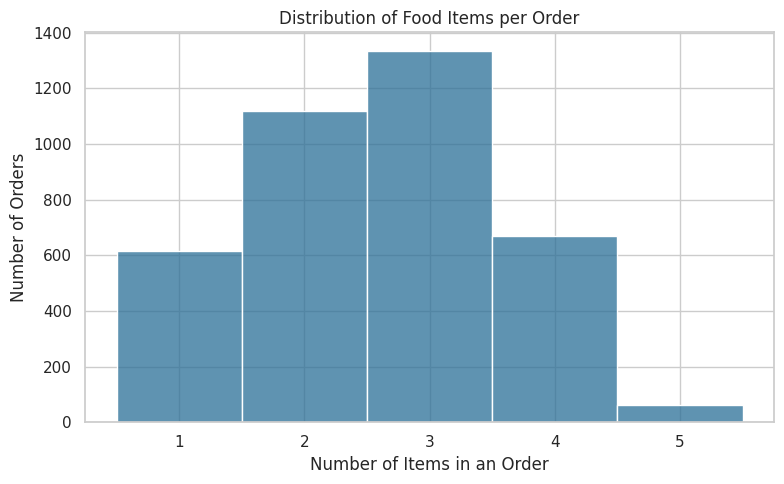

In [4]:
orders.info()

print("\nMissing values by column:")
display(
    orders.isna()
    .sum()
    .to_frame("missing_count")
)

basket_sizes = orders.groupby(
    "order_id"
).size()

basket_size_summary = pd.DataFrame(
    {
        "value": [
            basket_sizes.count(),
            basket_sizes.mean(),
            basket_sizes.median(),
            basket_sizes.min(),
            basket_sizes.max(),
        ]
    },
    index=[
        "number_of_orders",
        "mean_items_per_order",
        "median_items_per_order",
        "minimum_items_per_order",
        "maximum_items_per_order",
    ]
)

print("\nBasket-size summary:")
display(basket_size_summary.round(2))

plt.figure(figsize=(8, 5))

sns.histplot(
    basket_sizes,
    discrete=True,
    color="#2A6F97"
)

plt.title("Distribution of Food Items per Order")
plt.xlabel("Number of Items in an Order")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

**Data Quality and Basket Size Interpretation**

The dataset has no missing values in the order ID, transaction date, item ID, item name, category, or price columns. Therefore, no incomplete order lines need to be removed or imputed.

The dataset contains 3,800 customer orders. Each order has an average of 2.59 food items, while the median order contains 3 items. Basket sizes range from 1 to 5 food items.

Most orders contain multiple food items, making the dataset suitable for association rule mining. These multi-item baskets can reveal food combinations that may be useful for bundles and checkout recommendations.

## 3. Build Transactions from Raw Order Lines

Association rule mining requires one transaction basket per order. The raw dataset contains one row per food item, so food item IDs must be grouped by `order_id`.

Only `item_id` will be included in each transaction basket. The order ID, transaction date, item name, category, and price are not food items and must not appear inside the baskets.

Item IDs will be used for mining because they are stable identifiers. Food names and categories will be used later to explain the rules in a readable form.

In [5]:
duplicate_order_items = orders.duplicated(
    subset=["order_id", "item_id"]
).sum()

transactions_by_order = (
    orders.groupby("order_id")["item_id"]
    .apply(lambda items: sorted(items.unique()))
)

transactions = transactions_by_order.tolist()

print(
    "Duplicate order-item pairs removed from baskets:",
    duplicate_order_items
)

print(
    f"Number of transaction baskets: {len(transactions)}"
)

print("\nFirst 5 transaction baskets using item IDs:")

for order_id, basket in transactions_by_order.head().items():
    print(f"Order {order_id}: {basket}")

Duplicate order-item pairs removed from baskets: 0
Number of transaction baskets: 3800

First 5 transaction baskets using item IDs:
Order 1: ['F04', 'F15']
Order 2: ['F13']
Order 3: ['F10', 'F11', 'F12']
Order 4: ['F07']
Order 5: ['F12', 'F14']


### Transaction Basket Interpretation

The raw order-line data was successfully grouped into 3,800 transaction baskets, with one basket for each customer order.

No duplicate order-item pairs were found. Each basket contains only stable food item IDs, such as `F04` and `F15`.

Order ID, transaction date, item name, category, and price were excluded from the baskets because they are not food items. Association rules will be mined using item IDs, while food names and categories will be used later to explain the final rules and recommendations.

In [6]:
item_lookup = (
    orders[
        [
            "item_id",
            "item_name",
            "category",
            "price_kes",
        ]
    ]
    .drop_duplicates(
        subset="item_id"
    )
    .set_index("item_id")
    .sort_index()
)

print(
    f"Unique items in lookup table: {len(item_lookup)}"
)

display(item_lookup)

Unique items in lookup table: 15


,item_name,category,price_kes
item_id,,,
F01,Beef Burger,Fast Food,450
F02,French Fries,Fast Food,200
F03,Soda,Beverages,100
F04,Chicken Wings,Fast Food,500
F05,Margherita Pizza,Italian,900
F06,Garlic Bread,Italian,250
F07,California Roll Sushi,Japanese,700
F08,Miso Soup,Japanese,150
F09,Green Tea,Beverages,100


## 4. Item Popularity and Support Context

Before selecting the minimum-support threshold, the popularity of each food item is examined.

Support represents the proportion of transaction baskets containing an item or item combination. The number of orders containing each food item helps us choose a support threshold that is appropriate for the 3,800 food-delivery transactions in this dataset.

,item_name,category,order_count,support
item_id,,,,
F02,French Fries,Fast Food,1027,0.2703
F03,Soda,Beverages,725,0.1908
F08,Miso Soup,Japanese,708,0.1863
F06,Garlic Bread,Italian,697,0.1834
F07,California Roll Sushi,Japanese,696,0.1832
F11,Raita,Indian,689,0.1813
F10,Chicken Biryani,Indian,681,0.1792
F12,Naan Bread,Indian,675,0.1776
F04,Chicken Wings,Fast Food,667,0.1755


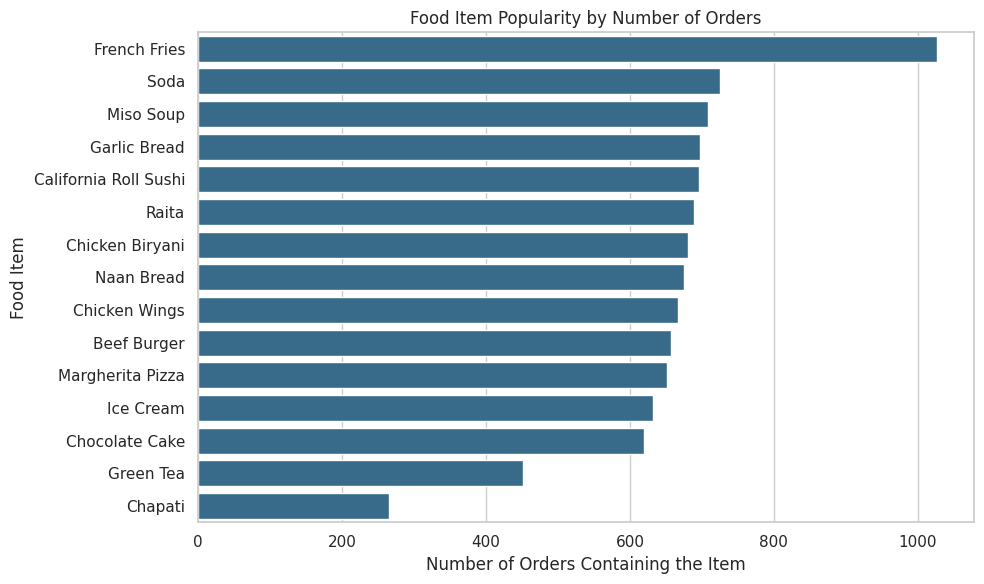

In [7]:
number_of_orders = len(transactions)

item_order_counts = (
    orders.groupby("item_id")["order_id"]
    .nunique()
    .rename("order_count")
)

item_popularity = (
    item_lookup
    .join(item_order_counts)
    .assign(
        support=lambda frame: (
            frame["order_count"] / number_of_orders
        )
    )
    .sort_values(
        "order_count",
        ascending=False
    )
)

display(
    item_popularity[
        [
            "item_name",
            "category",
            "order_count",
            "support",
        ]
    ].round(4)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=item_popularity.reset_index(),
    y="item_name",
    x="order_count",
    color="#2A6F97"
)

plt.title("Food Item Popularity by Number of Orders")
plt.xlabel("Number of Orders Containing the Item")
plt.ylabel("Food Item")

plt.tight_layout()
plt.show()

**Item Popularity Interpretation**

French Fries is the most frequently ordered food item. It appears in 1,027 orders, representing 27.03% of all food-delivery transactions.

Chapati is the least frequently ordered item. It appears in 265 orders, representing 6.97% of all transactions.

The other food items appear in approximately 12% to 19% of orders. This means that all 15 food items have enough transaction presence to be considered during association rule mining.

The minimum-support threshold will be selected using the 3,800 transaction count and a sensitivity check. A support value will be interpreted as the minimum number of orders in which an item combination must appear.

## 5. Frequent Itemsets and Minimum Support Selection

Association rule mining requires each order basket to be converted into a one-hot transaction matrix.

Each row represents one order and each column represents one food item. A value of `True` means that the food item was included in that order.

Several minimum-support values will be tested. This ensures that the final threshold is selected using the size and structure of this food-delivery dataset rather than copied from another dataset.

In [8]:
from mlxtend.frequent_patterns import apriori
from mlxtend.preprocessing import TransactionEncoder

transaction_encoder = TransactionEncoder()

transaction_onehot = transaction_encoder.fit(
    transactions
).transform(
    transactions
)

transaction_data = pd.DataFrame(
    transaction_onehot,
    columns=transaction_encoder.columns_
)

print(
    f"Transaction matrix shape: "
    f"{transaction_data.shape[0]} orders and "
    f"{transaction_data.shape[1]} food items"
)

support_candidates = [
    0.005,
    0.010,
    0.015,
    0.020,
    0.030,
]

support_sensitivity_results = []

for min_support in support_candidates:
    candidate_itemsets = apriori(
        transaction_data,
        min_support=min_support,
        use_colnames=True
    )

    support_sensitivity_results.append(
        {
            "min_support": min_support,
            "minimum_order_count": int(
                np.ceil(
                    min_support * len(transaction_data)
                )
            ),
            "frequent_itemset_count": len(
                candidate_itemsets
            ),
            "largest_itemset_size": (
                candidate_itemsets["itemsets"]
                .apply(len)
                .max()
            ),
        }
    )

support_sensitivity_df = pd.DataFrame(
    support_sensitivity_results
)

display(support_sensitivity_df)

Transaction matrix shape: 3800 orders and 15 food items


,min_support,minimum_order_count,frequent_itemset_count,largest_itemset_size
0,0.005,19,157,4
1,0.010,38,126,4
2,0.015,57,61,3
3,0.020,76,57,3
4,0.030,114,37,3


### Minimum Support Decision

Several minimum-support values were tested using the 3,800 transaction baskets.

A support of 0.005 requires an itemset to appear in at least 19 orders and produces 157 frequent itemsets. This is relatively permissive and may include weaker or less useful food combinations.

A support of 0.030 requires an itemset to appear in at least 114 orders and produces only 37 frequent itemsets. This may remove useful food combinations that occur regularly but are not among the most common orders.

A minimum support of 0.015 is selected. It requires an itemset to appear in at least 57 of the 3,800 orders and produces 61 frequent itemsets. This provides a manageable set of recurring food combinations while retaining itemsets containing up to three food items.

Apriori is used because the dataset contains only 15 food items, making its itemset search manageable and easy to interpret. The threshold was chosen from this dataset's transaction count and sensitivity results, not copied from another dataset.

In [9]:
MIN_SUPPORT = 0.015

minimum_support_count = int(
    np.ceil(
        MIN_SUPPORT * len(transaction_data)
    )
)

frequent_itemsets = apriori(
    transaction_data,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

frequent_itemsets["itemset_size"] = (
    frequent_itemsets["itemsets"]
    .apply(len)
)

frequent_itemsets = frequent_itemsets.sort_values(
    ["support", "itemset_size"],
    ascending=[False, True]
).reset_index(drop=True)

print(f"Minimum support: {MIN_SUPPORT:.3f}")

print(
    f"Minimum order count required: "
    f"{minimum_support_count} of "
    f"{len(transaction_data)} orders"
)

print(
    f"Frequent itemsets generated: "
    f"{len(frequent_itemsets)}"
)

print(
    f"Largest frequent itemset size: "
    f"{frequent_itemsets['itemset_size'].max()}"
)

display(frequent_itemsets.head(15))

Minimum support: 0.015
Minimum order count required: 57 of 3800 orders
Frequent itemsets generated: 61
Largest frequent itemset size: 3


,support,itemsets,itemset_size
0,0.270263,(F02),1
1,0.190789,(F03),1
2,0.186316,(F08),1
3,0.183421,(F06),1
4,0.183158,(F07),1
5,0.181316,(F11),1
6,0.179211,(F10),1
7,0.177632,(F12),1
8,0.175526,(F04),1
9,0.172895,(F01),1


### Frequent Itemset Interpretation

A minimum support of 0.015 was selected. This means that an itemset must appear in at least 57 of the 3,800 food-delivery orders to be considered frequent.

The Apriori algorithm generated 61 frequent itemsets. These include single food items, two-item combinations, and three-item combinations. The largest frequent itemsets contain three food items.

Single-item itemsets show food popularity. Multi-item itemsets show foods that are commonly ordered together. For example, `F07` and `F08` have a support of 0.1171, meaning California Roll Sushi and Miso Soup appeared together in approximately 445 orders.

Frequent co-occurrence alone does not confirm that one food item is a useful recommendation for another. Association rules will next be generated to measure confidence and lift.

## 6. Generate Association Rules

Association rules describe directional relationships between food items.

For a rule such as `{A} → {B}`:

- Support is the proportion of orders containing both A and B.
- Confidence is the proportion of orders containing B among orders that contain A.
- Lift compares the observed co-occurrence with what would be expected if A and B were independent.

A lift value above 1 suggests that the foods appear together more often than expected by chance.

In [10]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets[
        [
            "support",
            "itemsets",
        ]
    ],
    metric="lift",
    min_threshold=1.0
)

rules["antecedent_size"] = (
    rules["antecedents"]
    .apply(len)
)

rules["consequent_size"] = (
    rules["consequents"]
    .apply(len)
)

rules = rules.sort_values(
    [
        "lift",
        "confidence",
        "support",
    ],
    ascending=False
).reset_index(drop=True)

print(
    f"Candidate association rules generated: "
    f"{len(rules)}"
)

display(
    rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift",
        ]
    ]
    .head(15)
    .round(4)
)

Candidate association rules generated: 60


,antecedents,consequents,support,confidence,lift
0,"(F11, F10)",(F12),0.1024,0.9262,5.2141
1,(F12),"(F11, F10)",0.1024,0.5763,5.2141
2,"(F12, F10)",(F11),0.1024,0.9284,5.1204
3,(F11),"(F12, F10)",0.1024,0.5646,5.1204
4,(F10),"(F12, F11)",0.1024,0.5712,5.0130
5,"(F12, F11)",(F10),0.1024,0.8984,5.0130
6,"(F07, F09)",(F08),0.0455,0.8782,4.7134
7,(F08),"(F07, F09)",0.0455,0.2444,4.7134
8,"(F08, F09)",(F07),0.0455,0.8439,4.6075
9,(F07),"(F08, F09)",0.0455,0.2486,4.6075


### Candidate Association Rules

The Apriori frequent itemsets generated 60 candidate association rules with lift values of at least 1.0.

The candidate rules include different directions of the same food combination and rules with different numbers of items in the antecedent and consequent. For example, Chicken Biryani and Raita are strongly associated with Naan Bread.

At this stage, the candidate rules have not yet been filtered using confidence and lift thresholds. The distributions of confidence and lift will be examined before selecting the final strong rules.

,support,confidence,lift
count,60.0000,60.0000,60.0000
mean,0.0674,0.4633,3.0002
std,0.0315,0.2302,1.2393
min,0.0339,0.1383,1.1214
25%,0.0418,0.2475,1.8832
50%,0.0532,0.3973,3.1105
60%,0.0565,0.5543,3.3216
75%,0.1024,0.6198,3.5379
90%,0.1103,0.8274,4.7433
max,0.1171,0.9284,5.2141


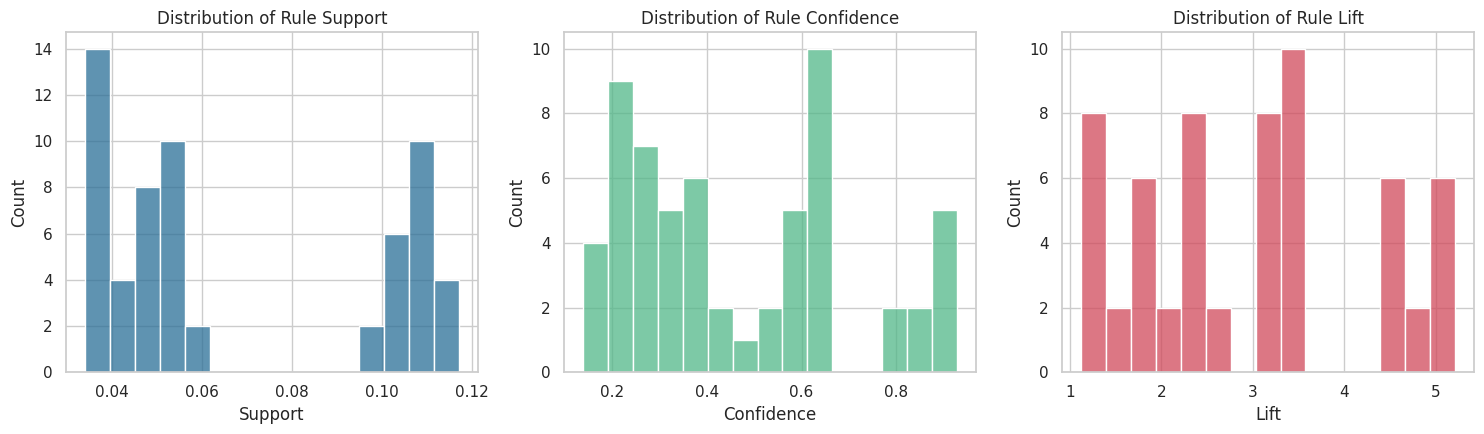

In [11]:
rule_distribution_summary = (
    rules[
        [
            "support",
            "confidence",
            "lift",
        ]
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.60,
            0.75,
            0.90,
        ]
    )
)

display(rule_distribution_summary.round(4))

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.5)
)

sns.histplot(
    rules["support"],
    bins=15,
    ax=axes[0],
    color="#2A6F97"
)

axes[0].set_title("Distribution of Rule Support")
axes[0].set_xlabel("Support")

sns.histplot(
    rules["confidence"],
    bins=15,
    ax=axes[1],
    color="#52B788"
)

axes[1].set_title("Distribution of Rule Confidence")
axes[1].set_xlabel("Confidence")

sns.histplot(
    rules["lift"],
    bins=15,
    ax=axes[2],
    color="#D1495B"
)

axes[2].set_title("Distribution of Rule Lift")
axes[2].set_xlabel("Lift")

plt.tight_layout()
plt.show()

## 7. Strong Rule Threshold Selection

The 60 candidate rules were examined before choosing the final confidence and lift thresholds.

The median confidence is 0.3973, while the 60th percentile is 0.5543. The median lift is 3.1105, while the 60th percentile is 3.3216.

A confidence threshold of 0.55 and a lift threshold of 3.30 are selected. These rounded values are close to the 60th percentiles of the observed rule distributions.

A confidence of 0.55 means that at least 55% of orders containing the antecedent food item or combination must also contain the consequent item or combination. A lift of 3.30 means that the foods must occur together at least 3.30 times more often than expected by chance.

These thresholds were selected from the actual food-delivery rule distributions. They are not universal values and would need to be reconsidered for a different dataset.

In [12]:
CONFIDENCE_THRESHOLD = 0.55
LIFT_THRESHOLD = 3.30

strong_rules = (
    rules[
        (
            rules["confidence"]
            >= CONFIDENCE_THRESHOLD
        )
        & (
            rules["lift"]
            >= LIFT_THRESHOLD
        )
    ]
    .sort_values(
        [
            "lift",
            "confidence",
            "support",
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    f"Strong rules with confidence >= "
    f"{CONFIDENCE_THRESHOLD:.2f} and lift >= "
    f"{LIFT_THRESHOLD:.2f}: "
    f"{len(strong_rules)}"
)

display(
    strong_rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift",
        ]
    ]
    .head(20)
    .round(4)
)

Strong rules with confidence >= 0.55 and lift >= 3.30: 20


,antecedents,consequents,support,confidence,lift
0,"(F11, F10)",(F12),0.1024,0.9262,5.2141
1,(F12),"(F11, F10)",0.1024,0.5763,5.2141
2,"(F12, F10)",(F11),0.1024,0.9284,5.1204
3,(F11),"(F12, F10)",0.1024,0.5646,5.1204
4,(F10),"(F12, F11)",0.1024,0.5712,5.0130
5,"(F12, F11)",(F10),0.1024,0.8984,5.0130
6,"(F07, F09)",(F08),0.0455,0.8782,4.7134
7,"(F08, F09)",(F07),0.0455,0.8439,4.6075
8,"(F06, F03)",(F05),0.0339,0.7771,4.5292
9,"(F05, F03)",(F06),0.0339,0.8113,4.4233


### Strong Rule Interpretation

Applying the confidence threshold of 0.55 and lift threshold of 3.30 produced 20 strong candidate association rules.

The strongest rule is `{F10, F11} → {F12}`. This means that when Chicken Biryani and Raita appear together in an order, Naan Bread also appears in 92.62% of those orders.

The rule has a lift of 5.2141. This means that the combination occurs about 5.21 times more often than expected if the food items were ordered independently.

Some of the 20 rules describe the same food relationship in reverse or use a more complex antecedent where a simpler rule already exists. These redundancies will be removed before the final rules are interpreted and used for recommendations.

## 8. Rule Filtering and Redundancy Removal

Two types of redundancy are removed from the strong rule set.

Subset redundancy occurs when a more complex rule has the same consequent as a simpler rule, but the simpler rule has equal or better confidence and lift.

Bidirectional redundancy occurs when the same food relationship appears in both directions, such as `{A} → {B}` and `{B} → {A}`. For a frequently-bought-together recommendation, both directions often represent the same underlying food combination.

The strongest direction is retained so that the final rule set is smaller, clearer, and more useful for recommendations.

In [13]:
def remove_subset_redundant_rules(rules_df):
    ordered_rules = rules_df.sort_values(
        ["lift", "confidence", "support"],
        ascending=False
    ).reset_index(drop=True)

    kept_rules = []

    for _, rule in ordered_rules.iterrows():
        is_redundant = False

        for kept_rule in kept_rules:
            same_consequent = (
                rule["consequents"]
                == kept_rule["consequents"]
            )

            more_complex_antecedent = (
                rule["antecedents"].issuperset(
                    kept_rule["antecedents"]
                )
                and rule["antecedents"]
                != kept_rule["antecedents"]
            )

            simpler_rule_is_at_least_as_strong = (
                kept_rule["confidence"]
                >= rule["confidence"]
                and kept_rule["lift"]
                >= rule["lift"]
            )

            if (
                same_consequent
                and more_complex_antecedent
                and simpler_rule_is_at_least_as_strong
            ):
                is_redundant = True
                break

        if not is_redundant:
            kept_rules.append(rule)

    return pd.DataFrame(
        kept_rules
    ).reset_index(drop=True)


def remove_bidirectional_redundancy(rules_df):
    ordered_rules = rules_df.sort_values(
        ["lift", "confidence", "support"],
        ascending=False
    ).reset_index(drop=True)

    seen_rule_pairs = set()
    kept_rules = []

    for _, rule in ordered_rules.iterrows():
        rule_pair = frozenset(
            [
                frozenset(rule["antecedents"]),
                frozenset(rule["consequents"]),
            ]
        )

        if rule_pair not in seen_rule_pairs:
            seen_rule_pairs.add(rule_pair)
            kept_rules.append(rule)

    return pd.DataFrame(
        kept_rules
    ).reset_index(drop=True)


rules_after_subset_filter = (
    remove_subset_redundant_rules(
        strong_rules
    )
)

cleaned_rules = remove_bidirectional_redundancy(
    rules_after_subset_filter
)

cleaned_rules = cleaned_rules.sort_values(
    ["lift", "confidence", "support"],
    ascending=False
).reset_index(drop=True)

print(
    f"Strong rules before filtering: "
    f"{len(strong_rules)}"
)

print(
    f"Rules after subset-redundancy removal: "
    f"{len(rules_after_subset_filter)}"
)

print(
    f"Rules after bidirectional-redundancy removal: "
    f"{len(cleaned_rules)}"
)

display(
    cleaned_rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift",
        ]
    ].round(4)
)

Strong rules before filtering: 20
Rules after subset-redundancy removal: 20
Rules after bidirectional-redundancy removal: 12


,antecedents,consequents,support,confidence,lift
0,"(F11, F10)",(F12),0.1024,0.9262,5.2141
1,"(F12, F10)",(F11),0.1024,0.9284,5.1204
2,(F10),"(F12, F11)",0.1024,0.5712,5.0130
3,"(F07, F09)",(F08),0.0455,0.8782,4.7134
4,"(F08, F09)",(F07),0.0455,0.8439,4.6075
5,"(F06, F03)",(F05),0.0339,0.7771,4.5292
6,"(F05, F03)",(F06),0.0339,0.8113,4.4233
7,(F12),(F11),0.1139,0.6415,3.5379
8,(F06),(F05),0.1092,0.5954,3.4702
9,(F12),(F10),0.1103,0.6207,3.4638


### Rule Filtering and Redundancy Removal Interpretation

The confidence and lift thresholds produced 20 strong candidate rules.

The subset-redundancy check retained all 20 rules. This means that no more complex rule had the same consequent as a simpler rule with equal or stronger confidence and lift.

The bidirectional-redundancy check reduced the rule set from 20 to 12 rules. It removed reverse versions of the same food relationship, such as `{A} → {B}` and `{B} → {A}`.

The cleaned rule set contains 12 distinct candidate food recommendations. These rules will now be translated from item IDs into readable food names before temporal validation.

## 9. Translate Rules into Human-Readable Food Names

Association rules are mined using stable food item IDs. The cleaned rules are now translated into food names using the item lookup table.

This translation is important because business users and customers need to see readable food names rather than item IDs such as `F10` or `F12`.

In [14]:
def itemset_to_ids(itemset):
    return ", ".join(
        sorted(itemset)
    )


def itemset_to_names(itemset):
    return ", ".join(
        sorted(
            item_lookup.loc[
                list(itemset),
                "item_name"
            ].tolist()
        )
    )


readable_rules = cleaned_rules.copy()

readable_rules["antecedent_item_ids"] = (
    readable_rules["antecedents"]
    .apply(itemset_to_ids)
)

readable_rules["consequent_item_ids"] = (
    readable_rules["consequents"]
    .apply(itemset_to_ids)
)

readable_rules["antecedent_foods"] = (
    readable_rules["antecedents"]
    .apply(itemset_to_names)
)

readable_rules["consequent_foods"] = (
    readable_rules["consequents"]
    .apply(itemset_to_names)
)

readable_rules["rule_description"] = (
    readable_rules["antecedent_foods"]
    + " → "
    + readable_rules["consequent_foods"]
)

display(
    readable_rules[
        [
            "rule_description",
            "support",
            "confidence",
            "lift",
        ]
    ]
    .round(4)
)

,rule_description,support,confidence,lift
0,"Chicken Biryani, Raita → Naan Bread",0.1024,0.9262,5.2141
1,"Chicken Biryani, Naan Bread → Raita",0.1024,0.9284,5.1204
2,"Chicken Biryani → Naan Bread, Raita",0.1024,0.5712,5.0130
3,"California Roll Sushi, Green Tea → Miso Soup",0.0455,0.8782,4.7134
4,"Green Tea, Miso Soup → California Roll Sushi",0.0455,0.8439,4.6075
5,"Garlic Bread, Soda → Margherita Pizza",0.0339,0.7771,4.5292
6,"Margherita Pizza, Soda → Garlic Bread",0.0339,0.8113,4.4233
7,Naan Bread → Raita,0.1139,0.6415,3.5379
8,Garlic Bread → Margherita Pizza,0.1092,0.5954,3.4702
9,Naan Bread → Chicken Biryani,0.1103,0.6207,3.4638


### Interpretation of Cleaned Association Rules

The cleaned rule set contains 12 distinct food-association rules after removing reverse-direction duplicates.

The strongest rule is Chicken Biryani and Raita → Naan Bread. It has a confidence of 0.9262, meaning that 92.62% of orders containing Chicken Biryani and Raita also contain Naan Bread. Its lift of 5.2141 shows that this combination occurs over five times more often than expected if the foods were ordered independently.

Other strong combinations include California Roll Sushi and Green Tea → Miso Soup, Garlic Bread and Soda → Margherita Pizza, and Naan Bread → Raita.

These rules suggest possible meal bundles and checkout recommendations. However, they are based on the same historical orders used to mine them. The rules must be validated on a later, unseen time period before they are treated as stable recommendations.

The rules show food co-occurrence patterns and do not prove that buying one food item causes a customer to buy another item.

## 10. Temporal Validation of Association Rules

Association rules do not have a target variable or a conventional train/test split. Instead, rules are validated using time.

Rules will be mined from earlier food-delivery orders and then checked against later orders. This tests whether the confidence of the discovered food combinations remains stable over time.

The transaction date will be used to create an approximately 80:20 chronological split. Orders before the cutoff date will form the rule-mining period, while orders on or after the cutoff date will form the validation period.

In [15]:
order_dates = (
    orders.groupby("order_id")["transaction_date"]
    .min()
    .sort_values()
)

daily_order_counts = (
    order_dates
    .value_counts()
    .sort_index()
)

temporal_split_candidates = pd.DataFrame(
    {
        "validation_start_date": daily_order_counts.index,
        "training_orders": (
            daily_order_counts
            .cumsum()
            .shift(fill_value=0)
        ),
    }
)

temporal_split_candidates["validation_orders"] = (
    len(order_dates)
    - temporal_split_candidates["training_orders"]
)

temporal_split_candidates["training_percentage"] = (
    temporal_split_candidates["training_orders"]
    / len(order_dates)
    * 100
)

temporal_split_candidates["distance_from_80_percent"] = (
    temporal_split_candidates["training_percentage"]
    - 80
).abs()

valid_cutoff_candidates = temporal_split_candidates[
    (
        temporal_split_candidates["training_orders"]
        > 0
    )
    & (
        temporal_split_candidates["validation_orders"]
        > 0
    )
]

selected_cutoff_row = (
    valid_cutoff_candidates
    .sort_values(
        "distance_from_80_percent"
    )
    .iloc[0]
)

CUTOFF_DATE = selected_cutoff_row[
    "validation_start_date"
]

print(
    f"Selected validation start date: "
    f"{CUTOFF_DATE.date()}"
)

print(
    f"Training orders before cutoff: "
    f"{int(selected_cutoff_row['training_orders'])}"
)

print(
    f"Validation orders on or after cutoff: "
    f"{int(selected_cutoff_row['validation_orders'])}"
)

print(
    f"Training percentage: "
    f"{selected_cutoff_row['training_percentage']:.2f}%"
)

cutoff_comparison = (
    valid_cutoff_candidates
    .sort_values(
        "distance_from_80_percent"
    )
    .head(5)[
        [
            "validation_start_date",
            "training_orders",
            "validation_orders",
            "training_percentage",
            "distance_from_80_percent",
        ]
    ]
)

display(cutoff_comparison)

Selected validation start date: 2025-05-24
Training orders before cutoff: 3037
Validation orders on or after cutoff: 763
Training percentage: 79.92%


,validation_start_date,training_orders,validation_orders,training_percentage,distance_from_80_percent
transaction_date,,,,,
2025-05-24,2025-05-24,3037,763,79.921053,0.078947
2025-05-25,2025-05-25,3063,737,80.605263,0.605263
2025-05-23,2025-05-23,3015,785,79.342105,0.657895
2025-05-26,2025-05-26,3080,720,81.052632,1.052632
2025-05-22,2025-05-22,2992,808,78.736842,1.263158


### Temporal Validation Split Decision

The food-delivery orders were divided into an earlier rule-mining period and a later validation period using `2025-05-24` as the cutoff date.

The earlier period contains 3,037 orders, representing 79.92% of all transactions. The later validation period contains 763 orders, representing 20.08% of all transactions.

The split follows time order. Rules will be mined using earlier orders and then checked against later orders. This provides a more realistic validation because a recommendation rule should remain useful for future customer orders, not only for the historical orders from which it was discovered.

In [16]:
train_orders = orders[
    orders["transaction_date"] < CUTOFF_DATE
].copy()

validation_orders = orders[
    orders["transaction_date"] >= CUTOFF_DATE
].copy()

train_transactions_by_order = (
    train_orders.groupby("order_id")["item_id"]
    .apply(lambda items: sorted(items.unique()))
)

validation_transactions_by_order = (
    validation_orders.groupby("order_id")["item_id"]
    .apply(lambda items: sorted(items.unique()))
)

train_transactions = train_transactions_by_order.tolist()

validation_transactions = (
    validation_transactions_by_order
    .tolist()
)

train_encoder = TransactionEncoder()

train_onehot = train_encoder.fit(
    train_transactions
).transform(
    train_transactions
)

train_transaction_data = pd.DataFrame(
    train_onehot,
    columns=train_encoder.columns_
)

validation_encoder = TransactionEncoder()

validation_onehot = validation_encoder.fit(
    validation_transactions
).transform(
    validation_transactions
)

validation_transaction_data_raw = pd.DataFrame(
    validation_onehot,
    columns=validation_encoder.columns_
)

validation_transaction_data = (
    validation_transaction_data_raw
    .reindex(
        columns=train_transaction_data.columns,
        fill_value=False
    )
)

validation_only_items = sorted(
    set(validation_transaction_data_raw.columns)
    - set(train_transaction_data.columns)
)

training_only_items = sorted(
    set(train_transaction_data.columns)
    - set(validation_transaction_data_raw.columns)
)

train_minimum_support_count = int(
    np.ceil(
        MIN_SUPPORT * len(train_transaction_data)
    )
)

train_frequent_itemsets = apriori(
    train_transaction_data,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

train_frequent_itemsets["itemset_size"] = (
    train_frequent_itemsets["itemsets"]
    .apply(len)
)

train_rules = association_rules(
    train_frequent_itemsets[
        [
            "support",
            "itemsets",
        ]
    ],
    metric="lift",
    min_threshold=1.0
)

train_strong_rules = (
    train_rules[
        (
            train_rules["confidence"]
            >= CONFIDENCE_THRESHOLD
        )
        & (
            train_rules["lift"]
            >= LIFT_THRESHOLD
        )
    ]
    .sort_values(
        [
            "lift",
            "confidence",
            "support",
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

train_rules_after_subset_filter = (
    remove_subset_redundant_rules(
        train_strong_rules
    )
)

train_cleaned_rules = (
    remove_bidirectional_redundancy(
        train_rules_after_subset_filter
    )
    .sort_values(
        [
            "lift",
            "confidence",
            "support",
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    f"Earlier rule-mining orders: "
    f"{len(train_transaction_data)}"
)

print(
    f"Later validation orders: "
    f"{len(validation_transaction_data)}"
)

print(
    f"Minimum support in earlier period: "
    f"{MIN_SUPPORT:.3f}"
)

print(
    f"Minimum earlier-period order count: "
    f"{train_minimum_support_count}"
)

print(
    f"Frequent itemsets mined in earlier period: "
    f"{len(train_frequent_itemsets)}"
)

print(
    f"Candidate rules mined in earlier period: "
    f"{len(train_rules)}"
)

print(
    f"Strong rules before filtering: "
    f"{len(train_strong_rules)}"
)

print(
    f"Rules after subset-redundancy removal: "
    f"{len(train_rules_after_subset_filter)}"
)

print(
    f"Rules after bidirectional-redundancy removal: "
    f"{len(train_cleaned_rules)}"
)

print(
    "\nItems appearing only in the validation period:"
)

print(
    validation_only_items
    if validation_only_items
    else "None"
)

print(
    "\nItems appearing only in the earlier period:"
)

print(
    training_only_items
    if training_only_items
    else "None"
)

display(
    train_cleaned_rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift",
        ]
    ]
    .round(4)
)

Earlier rule-mining orders: 3037
Later validation orders: 763
Minimum support in earlier period: 0.015
Minimum earlier-period order count: 46
Frequent itemsets mined in earlier period: 62
Candidate rules mined in earlier period: 64
Strong rules before filtering: 20
Rules after subset-redundancy removal: 20
Rules after bidirectional-redundancy removal: 12

Items appearing only in the validation period:
None

Items appearing only in the earlier period:
None


,antecedents,consequents,support,confidence,lift
0,"(F11, F10)",(F12),0.1004,0.9299,5.2008
1,"(F12, F10)",(F11),0.1004,0.9215,5.1632
2,(F10),"(F12, F11)",0.1004,0.5701,5.0923
3,"(F08, F09)",(F07),0.0454,0.8415,4.6804
4,"(F07, F09)",(F08),0.0454,0.8734,4.6293
5,"(F06, F03)",(F05),0.0342,0.7820,4.5063
6,"(F05, F03)",(F06),0.0342,0.7879,4.3505
7,(F11),(F12),0.1120,0.6273,3.5085
8,(F08),(F07),0.1179,0.6248,3.4752
9,(F10),(F12),0.1090,0.6187,3.4603


### Earlier-Period Rule Mining Results

The earlier order period contains 3,037 transactions. The same minimum support of 0.015 was applied, which requires an itemset to appear in at least 46 earlier-period orders.

The earlier-period data produced 62 frequent itemsets, 64 candidate rules, and 20 strong rules after applying the confidence and lift thresholds. After removing bidirectional redundancy, 12 cleaned rules remained.

All food item IDs appeared in both the earlier and later periods. Therefore, every cleaned rule can be checked against the later validation orders.

### Validation of Rule Confidence

The cleaned rules were mined using only the earlier order period. Their confidence will now be recalculated using the later validation period.

A rule is considered more stable when its validation confidence is close to its earlier-period confidence. A large drop in confidence suggests that a rule may reflect a temporary ordering pattern rather than a stable food combination.

In [17]:
def calculate_rule_metrics(
    onehot_data,
    antecedents,
    consequents
):
    antecedent_items = list(antecedents)
    consequent_items = list(consequents)

    antecedent_mask = onehot_data[
        antecedent_items
    ].all(axis=1)

    consequent_mask = onehot_data[
        consequent_items
    ].all(axis=1)

    both_mask = antecedent_mask & consequent_mask

    antecedent_order_count = antecedent_mask.sum()
    consequent_order_count = consequent_mask.sum()
    joint_order_count = both_mask.sum()

    support = (
        joint_order_count / len(onehot_data)
    )

    if antecedent_order_count == 0:
        confidence = np.nan
    else:
        confidence = (
            joint_order_count
            / antecedent_order_count
        )

    if consequent_order_count == 0:
        lift = np.nan
    else:
        consequent_support = (
            consequent_order_count
            / len(onehot_data)
        )

        lift = confidence / consequent_support

    return {
        "support": support,
        "confidence": confidence,
        "lift": lift,
        "antecedent_order_count": antecedent_order_count,
        "joint_order_count": joint_order_count,
    }


validation_results = []

for _, rule in train_cleaned_rules.iterrows():
    validation_metrics = calculate_rule_metrics(
        validation_transaction_data,
        rule["antecedents"],
        rule["consequents"]
    )

    validation_results.append(
        {
            "antecedents": rule["antecedents"],
            "consequents": rule["consequents"],
            "train_support": rule["support"],
            "train_confidence": rule["confidence"],
            "train_lift": rule["lift"],
            "validation_support": (
                validation_metrics["support"]
            ),
            "validation_confidence": (
                validation_metrics["confidence"]
            ),
            "validation_lift": (
                validation_metrics["lift"]
            ),
            "validation_antecedent_order_count": (
                validation_metrics[
                    "antecedent_order_count"
                ]
            ),
            "validation_joint_order_count": (
                validation_metrics[
                    "joint_order_count"
                ]
            ),
        }
    )

validation_df = pd.DataFrame(
    validation_results
)

validation_df["confidence_change"] = (
    validation_df["validation_confidence"]
    - validation_df["train_confidence"]
)

validation_df["absolute_confidence_change"] = (
    validation_df["confidence_change"]
    .abs()
)

validation_df = validation_df.sort_values(
    "absolute_confidence_change",
    ascending=False
).reset_index(drop=True)

print(
    "Mean absolute confidence change:",
    f"{validation_df['absolute_confidence_change'].mean():.4f}"
)

print(
    "Largest absolute confidence change:",
    f"{validation_df['absolute_confidence_change'].max():.4f}"
)

display(
    validation_df[
        [
            "antecedents",
            "consequents",
            "train_confidence",
            "validation_confidence",
            "confidence_change",
            "train_lift",
            "validation_lift",
            "validation_antecedent_order_count",
        ]
    ]
    .round(4)
)

Mean absolute confidence change: 0.0313
Largest absolute confidence change: 0.1380


,antecedents,consequents,train_confidence,validation_confidence,confidence_change,train_lift,validation_lift,validation_antecedent_order_count
0,"(F05, F03)",(F06),0.7879,0.9259,0.1380,4.3505,4.8060,27
1,(F05),(F06),0.6243,0.6880,0.0637,3.4472,3.5710,125
2,"(F12, F10)",(F11),0.9215,0.9545,0.0331,5.1632,4.9545,88
3,"(F06, F03)",(F05),0.7820,0.7576,-0.0244,4.5063,4.6242,33
4,"(F07, F09)",(F08),0.8734,0.8974,0.0240,4.6293,5.0722,39
5,(F08),(F07),0.6248,0.6444,0.0197,3.4752,3.2781,135
6,(F10),(F11),0.6131,0.6301,0.0171,3.4353,3.2707,146
7,"(F11, F10)",(F12),0.9299,0.9130,-0.0168,5.2008,5.2777,92
8,(F10),(F12),0.6187,0.6027,-0.0160,3.4603,3.4840,146
9,"(F08, F09)",(F07),0.8415,0.8537,0.0122,4.6804,4.3423,41


### Interpretation of Temporal Rule Validation

The 12 cleaned rules mined from the earlier order period were checked against 763 later food-delivery orders.

The mean absolute confidence change was 0.0313, meaning that rule confidence changed by approximately 3.13 percentage points on average between the earlier and later periods.

The largest absolute confidence change was 0.1380. This was an increase for the rule Soda and Margherita Pizza → Garlic Bread. The rule had only 27 validation orders containing its antecedent, so its confidence is more likely to vary than rules with larger antecedent counts.

A confidence shift of 0.15, or 15 percentage points, is used as the threshold for a meaningful change. No rule exceeded this threshold. Therefore, the cleaned rules appear stable across the earlier and later order periods.

This temporal validation increases confidence that the food combinations are not only historical coincidences from the earlier period. However, the rules should still be re-mined periodically because customer food-order patterns may change over time.

In [18]:
CONFIDENCE_SHIFT_THRESHOLD = 0.15

unstable_rules = validation_df[
    validation_df[
        "absolute_confidence_change"
    ] > CONFIDENCE_SHIFT_THRESHOLD
].copy()

rules_with_large_decline = validation_df[
    validation_df[
        "confidence_change"
    ] < -CONFIDENCE_SHIFT_THRESHOLD
].copy()

print(
    f"Rules with an absolute confidence shift greater than "
    f"{CONFIDENCE_SHIFT_THRESHOLD:.2f}: "
    f"{len(unstable_rules)}"
)

print(
    f"Rules with a confidence decline greater than "
    f"{CONFIDENCE_SHIFT_THRESHOLD:.2f}: "
    f"{len(rules_with_large_decline)}"
)

if unstable_rules.empty:
    print(
        "\nNo cleaned rules showed a meaningful "
        "confidence shift between periods."
    )
else:
    display(
        unstable_rules[
            [
                "antecedents",
                "consequents",
                "train_confidence",
                "validation_confidence",
                "confidence_change",
            ]
        ]
        .round(4)
    )

Rules with an absolute confidence shift greater than 0.15: 0
Rules with a confidence decline greater than 0.15: 0

No cleaned rules showed a meaningful confidence shift between periods.


### Temporal Validation Interpretation

The 12 cleaned association rules were mined using the earlier order period and then tested on 763 later orders.

The mean absolute confidence change was 0.0313, meaning that rule confidence changed by approximately 3.13 percentage points on average between the earlier and later periods.

The largest absolute confidence change was 0.1380, which is below the selected meaningful-change threshold of 0.15. No rule had a confidence decline greater than 0.15.

Therefore, none of the cleaned rules showed a meaningful loss of confidence in the later period. The food combinations appear stable enough to use for recommendations, although they should be re-mined periodically because customer ordering behaviour can change over time.

## 11. Visualize the Final Association Rules

The cleaned association rules are visualized using support, confidence, and lift.

Support shows how often a rule occurs in all orders. Confidence shows how often the consequent appears when the antecedent appears. Lift shows how much stronger the food combination is than expected by chance.

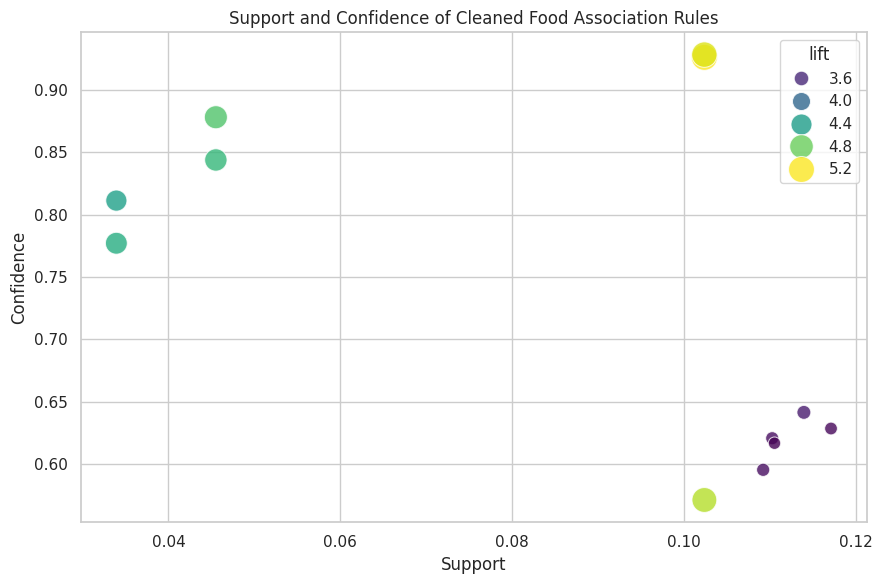

In [19]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=readable_rules,
    x="support",
    y="confidence",
    size="lift",
    hue="lift",
    palette="viridis",
    sizes=(80, 350),
    alpha=0.8
)

plt.title(
    "Support and Confidence of Cleaned Food Association Rules"
)

plt.xlabel("Support")
plt.ylabel("Confidence")

plt.tight_layout()
plt.show()

## 12. From Rules to Recommendations

The validated cleaned rules are converted into a recommendation lookup structure.

For each antecedent food combination, the lookup stores the possible recommended food items. When a customer has a cart, all matching rules are considered. Recommendations are ranked by confidence and then lift.

Food items already present in the cart will not be recommended again.

In [20]:
def build_recommendation_lookup(rules_df):
    lookup = {}

    for _, rule in rules_df.iterrows():
        antecedent = frozenset(
            rule["antecedents"]
        )

        for item_id in rule["consequents"]:
            candidate = {
                "item_id": item_id,
                "confidence": rule["confidence"],
                "lift": rule["lift"],
                "support": rule["support"],
            }

            antecedent_candidates = lookup.setdefault(
                antecedent,
                {}
            )

            existing_candidate = antecedent_candidates.get(
                item_id
            )

            if (
                existing_candidate is None
                or (
                    candidate["confidence"],
                    candidate["lift"],
                    candidate["support"],
                )
                > (
                    existing_candidate["confidence"],
                    existing_candidate["lift"],
                    existing_candidate["support"],
                )
            ):
                antecedent_candidates[item_id] = candidate

    ranked_lookup = {}

    for antecedent, candidates in lookup.items():
        ranked_lookup[antecedent] = sorted(
            candidates.values(),
            key=lambda candidate: (
                candidate["confidence"],
                candidate["lift"],
                candidate["support"],
            ),
            reverse=True,
        )

    return ranked_lookup


recommendation_lookup = build_recommendation_lookup(
    cleaned_rules
)

lookup_summary = []

for antecedent, recommendations in recommendation_lookup.items():
    lookup_summary.append(
        {
            "antecedent_item_ids": ", ".join(
                sorted(antecedent)
            ),
            "available_recommendations": len(
                recommendations
            ),
        }
    )

lookup_summary_df = pd.DataFrame(
    lookup_summary
).sort_values(
    "available_recommendations",
    ascending=False
)

print(
    f"Distinct antecedent combinations in lookup: "
    f"{len(recommendation_lookup)}"
)

display(lookup_summary_df)

Distinct antecedent combinations in lookup: 10


,antecedent_item_ids,available_recommendations
7,F12,2
2,F10,2
1,"F10, F12",1
0,"F10, F11",1
4,"F08, F09",1
3,"F07, F09",1
5,"F03, F06",1
6,"F03, F05",1
8,F06,1
9,F08,1


### Recommendation Function

The recommendation function checks every rule antecedent that is contained in a customer cart.

It considers all matching rules, removes food items already in the cart, and ranks the remaining recommendations by confidence and lift. The final output uses readable food names rather than item IDs.

In [21]:
def recommend_foods(
    cart_item_ids,
    lookup,
    lookup_table,
    top_n=3
):
    cart_item_ids = set(cart_item_ids)

    candidates = {}
    matched_antecedents = []

    for antecedent, recommendations in lookup.items():
        if antecedent.issubset(cart_item_ids):
            matched_antecedents.append(
                tuple(sorted(antecedent))
            )

            for recommendation in recommendations:
                item_id = recommendation["item_id"]

                if item_id not in cart_item_ids:
                    existing = candidates.get(item_id)

                    if (
                        existing is None
                        or (
                            recommendation["confidence"],
                            recommendation["lift"],
                            recommendation["support"],
                        )
                        > (
                            existing["confidence"],
                            existing["lift"],
                            existing["support"],
                        )
                    ):
                        candidates[item_id] = recommendation

    ranked_recommendations = sorted(
        candidates.values(),
        key=lambda recommendation: (
            recommendation["confidence"],
            recommendation["lift"],
            recommendation["support"],
        ),
        reverse=True,
    )[:top_n]

    recommendation_results = []

    for recommendation in ranked_recommendations:
        item_id = recommendation["item_id"]

        recommendation_results.append(
            {
                "item_id": item_id,
                "item_name": lookup_table.loc[
                    item_id,
                    "item_name"
                ],
                "category": lookup_table.loc[
                    item_id,
                    "category"
                ],
                "confidence": recommendation[
                    "confidence"
                ],
                "lift": recommendation["lift"],
                "support": recommendation["support"],
            }
        )

    return (
        pd.DataFrame(recommendation_results),
        matched_antecedents,
    )


example_cart = {"F10"}

recommendation_results, matched_antecedents = (
    recommend_foods(
        example_cart,
        recommendation_lookup,
        item_lookup,
        top_n=3
    )
)

print(
    "Cart items:"
)

print(
    item_lookup.loc[
        sorted(example_cart),
        "item_name"
    ].tolist()
)

print(
    "\nMatched rule antecedents:"
)

print(matched_antecedents)

print("\nRecommended foods:")

display(
    recommendation_results.round(4)
)

Cart items:
['Chicken Biryani']

Matched rule antecedents:
[('F10',)]

Recommended foods:


,item_id,item_name,category,confidence,lift,support
0,F11,Raita,Indian,0.6167,3.4015,0.1105
1,F12,Naan Bread,Indian,0.5712,5.0130,0.1024


### Recommendation Function Interpretation

The recommendation function successfully used the validated association rules to generate food recommendations for a cart containing Chicken Biryani.

For this cart, the function recommended Raita and Naan Bread. Raita had the highest confidence of 0.6167, meaning that approximately 61.67% of orders containing Chicken Biryani also contained Raita.

Naan Bread had a confidence of 0.5712 and a higher lift of 5.0130. This means that Chicken Biryani and Naan Bread appeared together about five times more often than expected if the two foods were ordered independently.

The function considered all matching rules, excluded food items already in the cart, and returned recommendations using readable food names rather than item IDs.

In [22]:
multi_item_cart = {
    "F10",
    "F11",
}

multi_item_recommendations, multi_item_matches = (
    recommend_foods(
        multi_item_cart,
        recommendation_lookup,
        item_lookup,
        top_n=3
    )
)

print("Cart items:")

print(
    item_lookup.loc[
        sorted(multi_item_cart),
        "item_name"
    ].tolist()
)

print("\nMatched rule antecedents:")

print(multi_item_matches)

print("\nRecommended foods:")

display(
    multi_item_recommendations.round(4)
)

Cart items:
['Chicken Biryani', 'Raita']

Matched rule antecedents:
[('F10', 'F11'), ('F10',)]

Recommended foods:


,item_id,item_name,category,confidence,lift,support
0,F12,Naan Bread,Indian,0.9262,5.2141,0.1024


### Multiple-Rule Recommendation Interpretation

The cart containing Chicken Biryani and Raita matched two rule antecedents: Chicken Biryani alone and the combined Chicken Biryani and Raita basket.

The recommendation function considered both matching rules. It excluded Chicken Biryani and Raita because they were already in the cart.

Naan Bread was recommended because the combined rule Chicken Biryani and Raita → Naan Bread had the strongest confidence of 0.9262 and a lift of 5.2141.

This demonstrates that the recommendation function does not stop at the first matching rule. It considers all relevant rules and returns the strongest available food recommendation.

## 13. Rules and Recommendation Persistence

The cleaned association rules, recommendation lookup structure, and food-item lookup table are saved together.

Saving all three objects is important because the rules alone are not enough to produce readable recommendations. The recommendation lookup is used to find matching rules efficiently, while the item lookup translates food item IDs into readable food names.

In [23]:
rules_path = (
    "d10_food_delivery_recommendation_rules.joblib"
)

rules_artifact = {
    "cleaned_rules": cleaned_rules,
    "readable_rules": readable_rules,
    "recommendation_lookup": recommendation_lookup,
    "item_lookup": item_lookup,
    "min_support": MIN_SUPPORT,
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "lift_threshold": LIFT_THRESHOLD,
    "cutoff_date": CUTOFF_DATE,
    "validation_results": validation_df,
}

joblib.dump(
    rules_artifact,
    rules_path
)

loaded_rules_artifact = joblib.load(
    rules_path
)

print(
    "Rules artifact saved and reloaded:"
)

print(rules_path)

print(
    "\nSaved cleaned rules:"
)

print(
    len(
        loaded_rules_artifact["cleaned_rules"]
    )
)

print(
    "\nSaved antecedent combinations:"
)

print(
    len(
        loaded_rules_artifact[
            "recommendation_lookup"
        ]
    )
)

print(
    "\nSaved item lookup entries:"
)

print(
    len(
        loaded_rules_artifact["item_lookup"]
    )
)

Rules artifact saved and reloaded:
d10_food_delivery_recommendation_rules.joblib

Saved cleaned rules:
12

Saved antecedent combinations:
10

Saved item lookup entries:
15


### Reloaded Recommendation Demonstration

The saved rules artifact is reloaded and used to make recommendations for a new food basket.

This confirms that the cleaned rules, recommendation lookup, and food-item lookup can be reused without rebuilding the association-rule model from the original transaction data.

In [24]:
loaded_lookup = loaded_rules_artifact[
    "recommendation_lookup"
]

loaded_item_lookup = loaded_rules_artifact[
    "item_lookup"
]

new_cart = {
    "F07",
    "F09",
}

new_cart_recommendations, new_cart_matches = (
    recommend_foods(
        new_cart,
        loaded_lookup,
        loaded_item_lookup,
        top_n=3
    )
)

print("New cart items:")

print(
    loaded_item_lookup.loc[
        sorted(new_cart),
        "item_name"
    ].tolist()
)

print("\nMatched rule antecedents:")

print(new_cart_matches)

print("\nRecommendations from reloaded rules:")

display(
    new_cart_recommendations.round(4)
)

print(
    f"\nInput cart items: {len(new_cart)}"
)

print(
    f"Recommendations returned: "
    f"{len(new_cart_recommendations)}"
)

New cart items:
['California Roll Sushi', 'Green Tea']

Matched rule antecedents:
[('F07', 'F09')]

Recommendations from reloaded rules:


,item_id,item_name,category,confidence,lift,support
0,F08,Miso Soup,Japanese,0.8782,4.7134,0.0455



Input cart items: 2
Recommendations returned: 1


### Persisted Recommendation Interpretation

The saved recommendation artifact was reloaded successfully and used to recommend food items for a new customer cart.

The cart contained California Roll Sushi and Green Tea. The reloaded recommendation lookup matched this food combination and recommended Miso Soup.

The recommendation has a confidence of 0.8782, meaning that approximately 87.82% of historical orders containing California Roll Sushi and Green Tea also contained Miso Soup.

The lift is 4.7134, meaning that this food combination occurred about 4.71 times more often than expected if the items were ordered independently.

The persisted rules artifact received two cart items and returned one readable food recommendation. This demonstrates that the saved cleaned rules, recommendation lookup, and item lookup can be reused without rebuilding the association-rule model from the original order data.

## 14. Academic and Business Report

### Limitations and Diagnostic Findings

This analysis used 9,842 food-order lines from 3,800 customer orders between 1 January 2025 and 30 June 2025. The rules were mined using 15 food items and do not use customer-level preferences, delivery location, time of day, promotions, or restaurant availability.

A minimum support of 0.015 was selected after testing several support values. This required an itemset to appear in at least 57 of the 3,800 orders. The full dataset produced 61 frequent itemsets, 60 candidate rules, 20 strong rules after applying confidence and lift thresholds, and 12 cleaned rules after bidirectional redundancy removal.

The final rules were validated using a chronological split. Rules were mined on 3,037 earlier orders before 24 May 2025 and checked on 763 later orders. The mean absolute confidence change was 0.0313, while the largest confidence change was 0.1380. No cleaned rule had an absolute confidence change greater than 0.15, and no rule had a confidence decline greater than 0.15.

This suggests that the final food associations remained stable during the later validation period. However, customer ordering patterns can change over time because of menu changes, seasonal demand, pricing, or promotions. The rules should therefore be re-mined and validated periodically.

### Group Academic Statement

As Group D10, we applied association rule mining to 3,800 food-delivery transactions using the Apriori algorithm. Transactions were created by grouping raw food-order lines by `order_id`, with stable `item_id` values used for mining and food names reserved for reporting.

A minimum support of 0.015, equivalent to at least 57 orders, produced 61 frequent itemsets. Association rules were generated using lift greater than or equal to 1.0. Confidence and lift thresholds were selected from the observed rule distributions. A confidence threshold of 0.55 and a lift threshold of 3.30 produced 20 strong candidate rules.

After removing bidirectional redundancy, 12 cleaned association rules remained. The strongest rules are shown below.

| Antecedent | Consequent | Support | Confidence | Lift |
|---|---|---:|---:|---:|
| Chicken Biryani, Raita | Naan Bread | 0.1024 | 0.9262 | 5.2141 |
| Chicken Biryani, Naan Bread | Raita | 0.1024 | 0.9284 | 5.1204 |
| Chicken Biryani | Naan Bread, Raita | 0.1024 | 0.5712 | 5.0130 |
| California Roll Sushi, Green Tea | Miso Soup | 0.0455 | 0.8782 | 4.7134 |
| Garlic Bread, Soda | Margherita Pizza | 0.0339 | 0.7771 | 4.5292 |

The rules show that these foods were ordered together more often than expected by chance. They describe statistical association and do not prove that buying one food item causes a customer to buy another.


### Business Analysis and Recommendations

The strongest rules suggest clear meal combinations that can support food bundles, checkout recommendations, and targeted promotions.

Chicken Biryani, Raita, and Naan Bread form the strongest food combination. When Chicken Biryani and Raita were ordered together, Naan Bread was also ordered in 92.62% of those orders. The food-delivery platform can use this combination as an Indian meal bundle or recommend Naan Bread at checkout when a customer adds Chicken Biryani and Raita.

California Roll Sushi and Green Tea strongly predict Miso Soup. This combination can be used for a Japanese meal recommendation or a discounted sushi-and-soup bundle.

Garlic Bread, Soda, and Margherita Pizza also form a strong Italian food combination. The platform can use this rule to suggest Garlic Bread when customers order Margherita Pizza and Soda.

The persisted recommendation function demonstrated this approach. A cart containing California Roll Sushi and Green Tea was recommended Miso Soup with a confidence of 0.8782 and a lift of 4.7134.

The business should use these rules as a recommendation and upselling tool, not as a fixed rule for every customer. The recommendations should be refreshed regularly as menus, prices, customer preferences, and ordering behaviour change.